### Лабораторная работа №4
#### Ковалев А.В. ИУ5-63Б
1. Импорт библиотек.

In [227]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from io import StringIO 
import pydotplus
from IPython.display import Image
from operator import itemgetter
from sklearn.model_selection import GridSearchCV

2. Загрузка и первичный анализ данных

In [228]:
students = pd.read_csv('Student_performance_data _.csv', sep=",")
print('Кол-во строк: ', students.shape[0],'\n' ,'Кол-во столбцов: ', students.shape[1], sep = '')
print(students.dtypes)
print('Пропуски по столбцам:', students.isnull().sum())
students.head(8)

Кол-во строк: 2392
Кол-во столбцов: 15
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object
Пропуски по столбцам: StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1.0
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2.0
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4.0


3. Выбор необходимых столбцов

<Axes: >

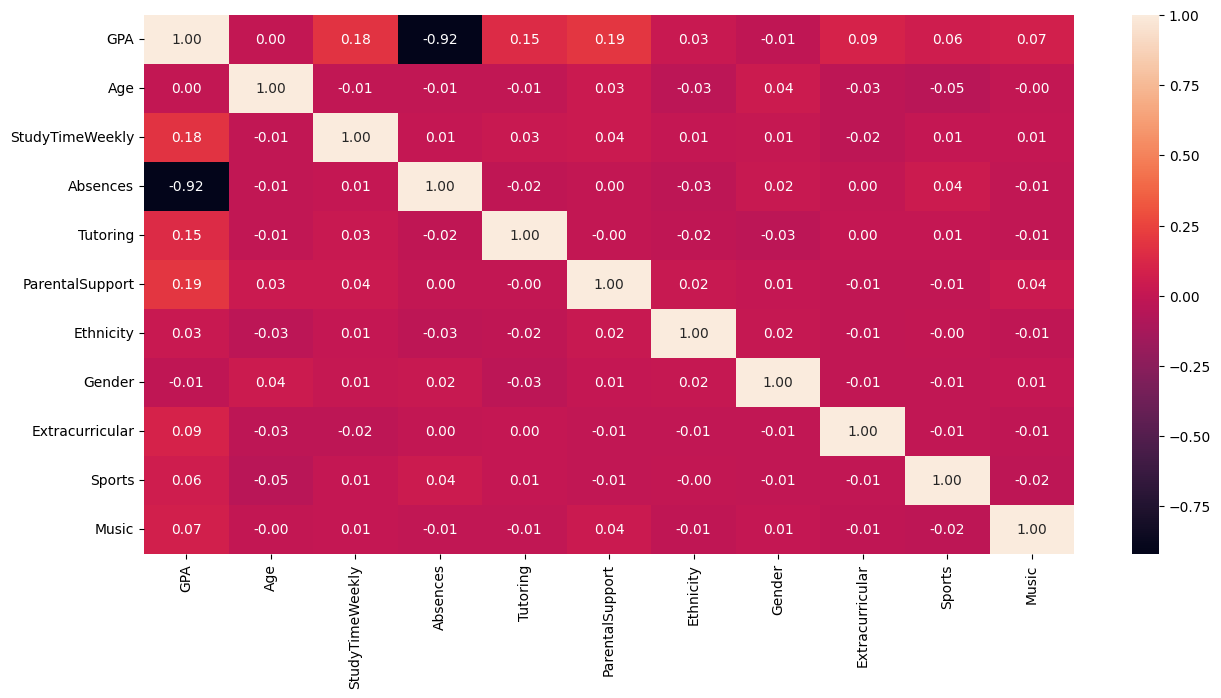

In [229]:
students_nec = students[["GPA", "Age", "StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport", "Ethnicity", "Gender", "Extracurricular", "Sports", "Music"]]


fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(students_nec.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

4. Выбор необходимых столбцов и составление тестовой выборки

In [230]:
students_nec = students[["GPA", "StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport"]]
GPA_X_train, GPA_X_test, GPA_y_train, GPA_y_test = train_test_split(
    students_nec[["StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport"]], students_nec["GPA"], test_size=0.2, random_state=1)

5. Полиномиальная регрессия

In [231]:
def train_poly_and_predict(GPA_X_train, degree):
    poly_model = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                       ('linear', LinearRegression(fit_intercept=False))])
    poly_model.fit(GPA_X_train, GPA_y_train)
    return poly_model.predict(GPA_X_test)

res_degree = 0
min_mae = 1
for degree in range(10):
    mae = mean_absolute_error(GPA_y_test, train_poly_and_predict(GPA_X_train,degree))
    if min_mae - mae > 0.005: 
        min_mae = mae
        res_degree = degree

poly_y_pred = train_poly_and_predict(GPA_X_train,res_degree)

print(f"Наиболее удачная степень для полиномиальной регрессии={res_degree} MAE={mean_absolute_error(GPA_y_test, poly_y_pred)}")



Наиболее удачная степень для полиномиальной регрессии=1 MAE=0.19124027060289714


6. Метод опорных векторов

In [232]:
svr_model = SVR()
svr_model.fit(GPA_X_train, GPA_y_train)
svr_y_pred = svr_model.predict(GPA_X_test)

7. Дерево решений

In [233]:

params = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [0.04, 0.06, 0.08],
    'max_features': [0.2, 0.4, 0.6, 0.8]
}

tree_model = GridSearchCV(estimator=DecisionTreeRegressor(random_state=1),
                    param_grid=params, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
tree_model.fit(GPA_X_train, GPA_y_train)

tree_y_pred = tree_model.predict(GPA_X_test)
-tree_model.best_score_, tree_model.best_params_

tree_model = DecisionTreeRegressor(max_depth=tree_model.best_params_['max_depth'], 
                                   random_state=1, 
                                   min_samples_leaf=tree_model.best_params_['min_samples_leaf'], 
                                   criterion='absolute_error', 
                                    max_features=tree_model.best_params_['max_features'])
tree_model.fit(GPA_X_train, GPA_y_train)
tree_y_pred = tree_model.predict(GPA_X_test)

8. Сравнение MAE и MSE для предсказаний, полученных с помощью трех разных моделей

In [234]:
print(f"MAE для полиномиальной регресии: {mean_absolute_error(GPA_y_test, poly_y_pred)}")
print(f"MSE для полиномиальной регресии: {mean_squared_error(GPA_y_test, poly_y_pred)}")
print(f"MAE для метода опорных векторов: {mean_absolute_error(GPA_y_test, svr_y_pred)}")
print(f"MSE для метода опорных векторов: {mean_squared_error(GPA_y_test, svr_y_pred)}")
print(f"MAE для дерева решений: {mean_absolute_error(GPA_y_test, tree_y_pred)}")
print(f"MSE для дерева решений: {mean_squared_error(GPA_y_test, tree_y_pred)}")

MAE для полиномиальной регресии: 0.19124027060289714
MSE для полиномиальной регресии: 0.057267066981766666
MAE для метода опорных векторов: 0.1929277825702782
MSE для метода опорных векторов: 0.057788404404519544
MAE для дерева решений: 0.27374880490999676
MSE для дерева решений: 0.11357163740068957


9. График важности признаков дерева решений

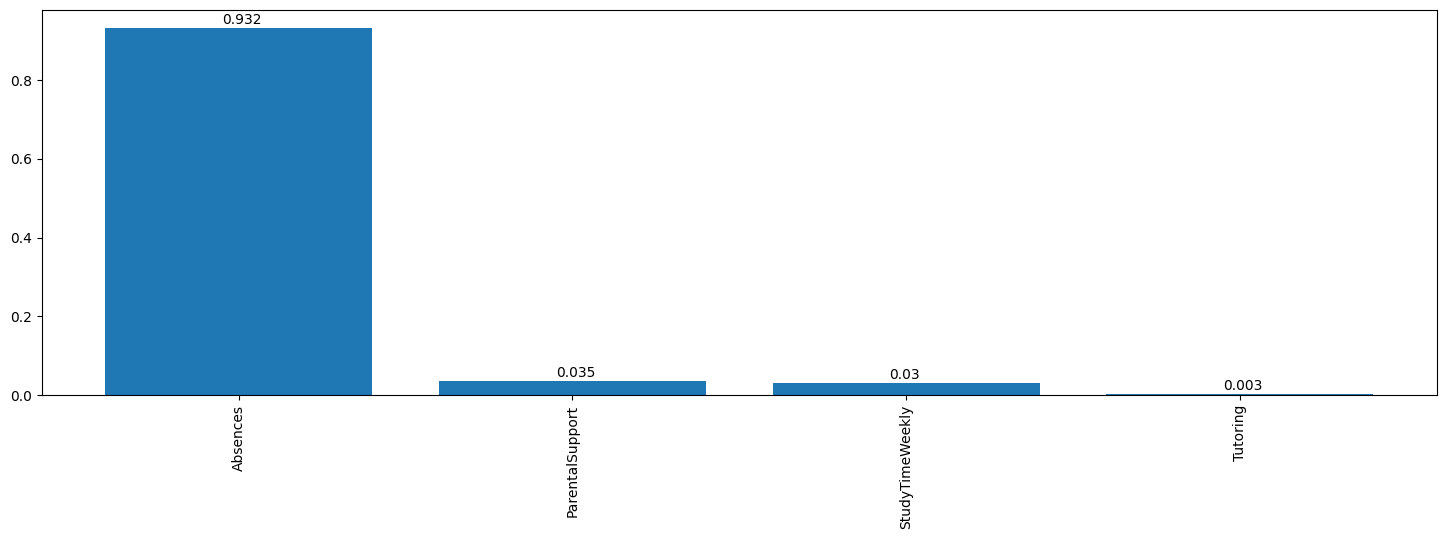

In [235]:
df_students_nec = students_nec[["StudyTimeWeekly", "Absences", "Tutoring", 
                         "ParentalSupport"]]

def draw_feature_importances(tree_model, X_dataset, figsize=(18,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data
iris_tree_cl_fl, iris_tree_cl_fd = draw_feature_importances(tree_model, df_students_nec)

10. Графическая визуализация дерева решений

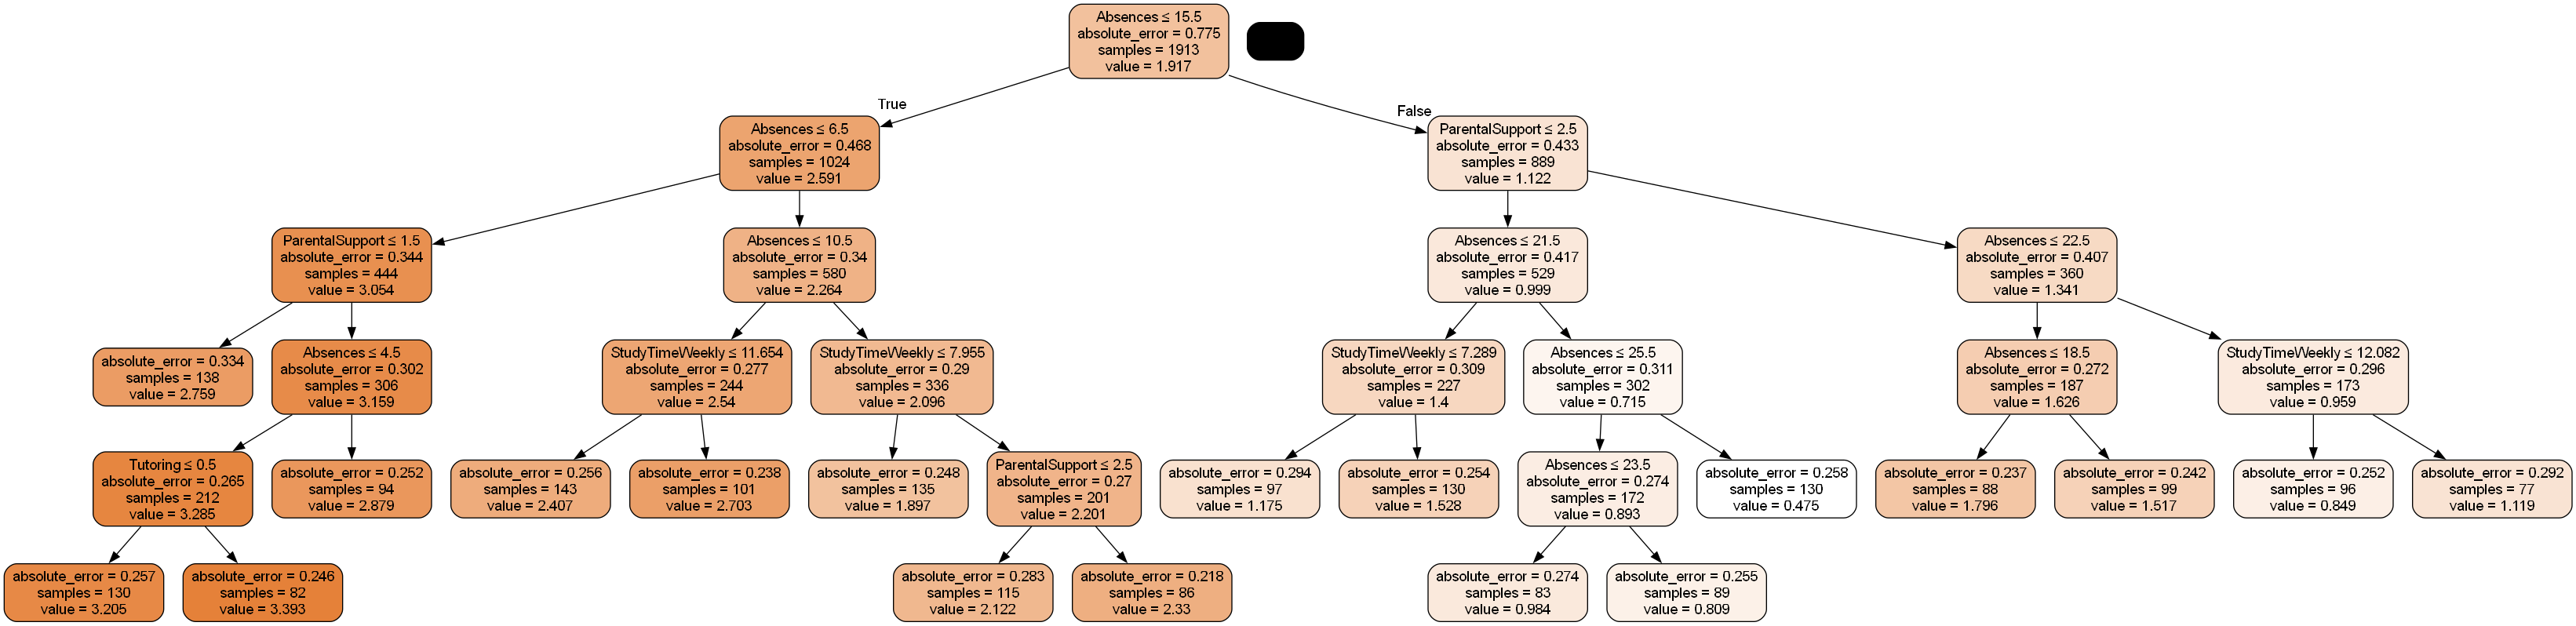

In [236]:
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

Image(get_png_tree(tree_model, df_students_nec.columns), height='200%')

11. Вывод дерева решений в текстовом виде

In [237]:
from sklearn.tree import export_text
from IPython.core.display import HTML
tree_rules = export_text(tree_model, feature_names=list(df_students_nec.columns))
HTML('<pre>' + tree_rules + '</pre>')